In [1]:
from math import exp
import numpy as np
import matplotlib.pyplot as plt
from operator import attrgetter

## Nonstationary Bandit Environment

In [2]:
# Gaussian Process with Radial Basis Function Kernel
def rbf_kernel(x1, x2, variance = 1):
    return exp(-1 * ((x1-x2) ** 2) / (2*variance))

def gram_matrix(xs,var):
    return [[rbf_kernel(x1,x2,variance=var) for x2 in xs] for x1 in xs]

def generate_mean_rewards(n_arms=5,smoothness=1):
    xs = np.arange(0, 5, 0.025)
    mean = [0 for x in xs]
    gram = gram_matrix(xs, var=smoothness)
        
    all_mean_rewards = []
    for i in range(n_arms):
        mus = np.random.multivariate_normal(mean, gram)
        all_mean_rewards.append(mus)
    return np.vstack(all_mean_rewards)

def generate_rewards(mean_rewards, noise_var=1):
    rewards = mean_rewards + np.random.normal(0,np.sqrt(noise_var),size=mean_rewards.shape)
    return rewards

## Examining the Nonstationary Environment

In [3]:
mean_rewards = generate_mean_rewards(smoothness=1)
mean_rewards.shape

(5, 200)

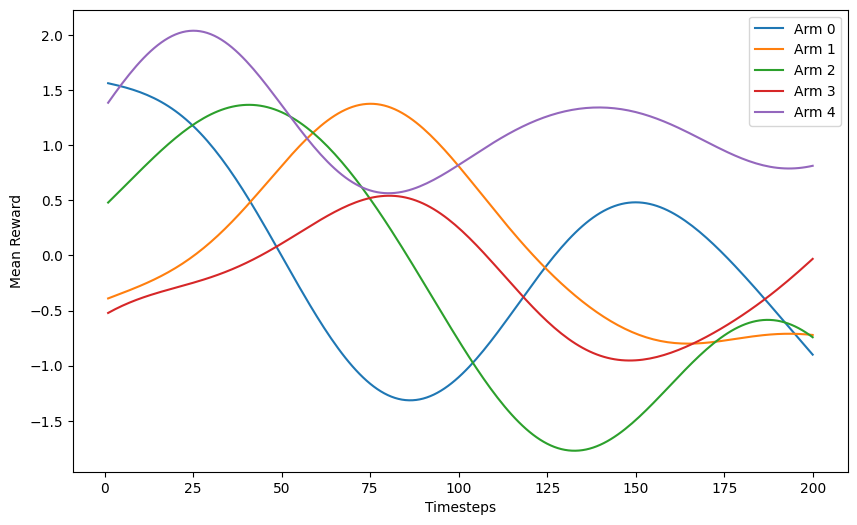

In [4]:
plt.figure(figsize=(10, 6))
for k in range(len(mean_rewards)):
    plt.plot(np.arange(1,len(mean_rewards[k])+1), mean_rewards[k], label='Arm {}'.format(k))
plt.ylabel('Mean Reward')
plt.xlabel('Timesteps')
plt.legend()
plt.show()

## Generating Rewards

In [5]:
rewards = generate_rewards(mean_rewards, noise_var=1)

## Solutions

In [6]:
class Arm:
    def __init__(self, index, mu_t_a, sigma):
        self.index = index
        self.numplays = 0.0
        self.mu_t_a = mu_t_a
        self.sigma = sigma
        self.totrew = 0.0
        self.avgrew = 0.0

    def sample(self, t):
        return np.random.normal(self.mu_t_a[t], self.sigma)

    def update(self, rew):
        self.numplays += 1
        self.totrew += rew
        self.avgrew = self.totrew / self.numplays

    def play(self, t):
        rew = self.sample(t)
        self.update(rew)
        return rew

    def reset(self):
        self.numplays = 0.0
        self.totrew = 0.0
        self.avgrew = 0.0

def GetArms(K, mu_t_a, sigma):
    arms = []
    for i in range(K):
        arms.append(Arm(i, mu_t_a[i], sigma))
    return arms

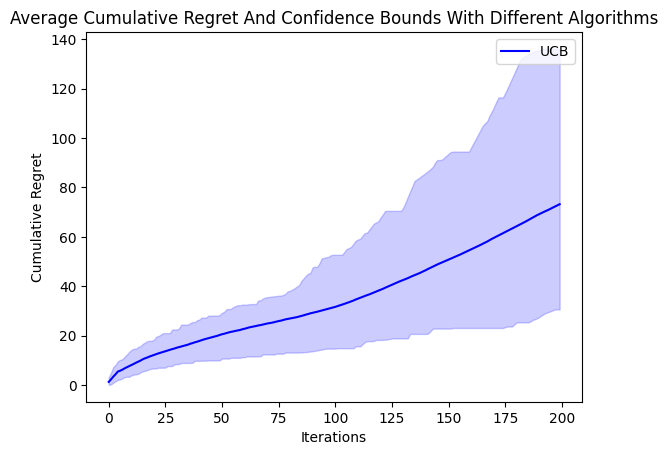

In [7]:
# might be worth changing the formula for cb
def UpdateCBs(arm, T, K):
    cb = np.sqrt(2 * arm.sigma**2 * (np.log(T * K)) / arm.numplays)
    arm.ucb = arm.avgrew + cb
    arm.lcb = arm.avgrew - cb

def UpperConfidenceBound(arms, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)

    for arm in arms:
        rew[t] = arm.play(t)
        reg[t] = max(arm.mu_t_a[t] for arm in arms) - arm.mu_t_a[t]
        UpdateCBs(arm, T, K)
        t += 1
        if t == T:
            break

    while t < T:
        arm = max(arms, key=attrgetter('ucb'))
        rew[t] = arm.play(t)
        reg[t] = max(arm.mu_t_a[t] for arm in arms) - arm.mu_t_a[t]
        UpdateCBs(arm, T, K)
        t += 1

    return rew, reg

K, T, sigma = 5, 200, 1
n_sim = 100
regrets = np.zeros((n_sim, T))

for simulation in range(n_sim):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, sigma)
    for arm in bandits_env:
        setattr(arm, 'ucb', 1000.0)
        setattr(arm, 'lcb', -1000.0)
    regrets[simulation] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])
    for arm in bandits_env:
        arm.reset()

mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[94]
CB5 = sorted_regrets[4]
plt.plot(mean_regrets, label='UCB', color='b')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='b')

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title('Average Cumulative Regret And Confidence Bounds With Different Algorithms')
plt.show()